# VisionOps Cycle - Image Classification\n
This notebook demonstrates preprocessing, optimization, model evaluation, and prediction correctness checks for the assignment rubric.

In [21]:
from pathlib import Path
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt

# Resolve project root robustly, with explicit fallback for this workspace
cwd = Path.cwd()
project_root = None

for p in [cwd, *cwd.parents]:
    if (p / 'src').exists() and (p / 'notebook').exists():
        project_root = p
        break

if project_root is None:
    explicit = Path('c:/Users/Kalivan/Documents/MLOP assignment')
    if (explicit / 'src').exists() and (explicit / 'notebook').exists():
        project_root = explicit

if project_root is None:
    raise RuntimeError('Could not locate project root containing src/ and notebook/.')

PROJECT_ROOT = project_root
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print('Using project root:', PROJECT_ROOT)

from src.preprocessing import acquire_flower_dataset, summarize_dataset_features
from src.model import train_and_evaluate
from src.prediction import predict_image

Using project root: c:\Users\Kalivan\Documents\MLOP assignment


## 1. Data Acquisition and Processing\n
Dataset is downloaded if missing, split into train/test folders, then feature summaries are generated.

In [22]:
train_dir, test_dir = acquire_flower_dataset('data')
print('Train dir:', train_dir)
print('Test dir:', test_dir)
summary_df = summarize_dataset_features('data/train', 'models/feature_summary.csv')
summary_df

Train dir: data\train
Test dir: data\test


,class_name,image_count,avg_width,avg_height,avg_brightness
0,daisy,506,360.391304,270.519763,102.522138
1,dandelion,718,365.888579,273.983287,97.291761
2,roses,512,361.960938,273.873047,101.860646
3,sunflowers,559,364.393560,271.483005,105.622052
4,tulips,639,374.258216,269.627543,100.713649


## 2. Model Training, Optimization, and Evaluation\n
Optimization techniques used: pretrained MobileNetV2 backbone, dropout regularization, L2 regularization, Adam optimizer, EarlyStopping, and ReduceLROnPlateau.

In [ ]:
metrics = train_and_evaluate(epochs=8, model_output_path='models/flower_classifier.keras')
print('Accuracy:', metrics['accuracy'])
print('Precision Macro:', metrics['precision_macro'])
print('Recall Macro:', metrics['recall_macro'])
print('F1 Macro:', metrics['f1_macro'])
print('Final Train Loss:', metrics['final_train_loss'])
print('Final Validation Loss:', metrics['final_val_loss'])

Found 2934 files belonging to 5 classes.
Found 736 files belonging to 5 classes.
Epoch 1/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step - accuracy: 0.6793 - loss: 0.8684 - val_accuracy: 0.8152 - val_loss: 0.5252 - learning_rate: 0.0010
Epoch 2/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.8327 - loss: 0.4788 - val_accuracy: 0.8410 - val_loss: 0.4490 - learning_rate: 0.0010
Epoch 3/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.8524 - loss: 0.4085 - val_accuracy: 0.8492 - val_loss: 0.4028 - learning_rate: 0.0010
Epoch 4/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step - accuracy: 0.8667 - loss: 0.3786 - val_accuracy: 0.8628 - val_loss: 0.3658 - learning_rate: 0.0010
Epoch 5/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 159s 2s/step - accuracy: 0.8746 - loss: 0.3374 - val_accuracy: 0.8668 - val_loss: 0.3591 - learning_rate: 0.0010
Epoch 6/8
92/92 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.8899 - loss: 0.3232 - val_accuracy: 0.8614 - val_loss: 0.3483 - learning_rate: 0.0010
Epoch 7/8


## 3. Visual Interpretation of 3 Features\n
Features interpreted: average width, average height, and average brightness by class.

,class_name,image_count,avg_width,avg_height,avg_brightness
0,daisy,506,360.391304,270.519763,102.522138
1,dandelion,718,365.888579,273.983287,97.291761
2,roses,512,361.960938,273.873047,101.860646
3,sunflowers,559,364.393560,271.483005,105.622052
4,tulips,639,374.258216,269.627543,100.713649


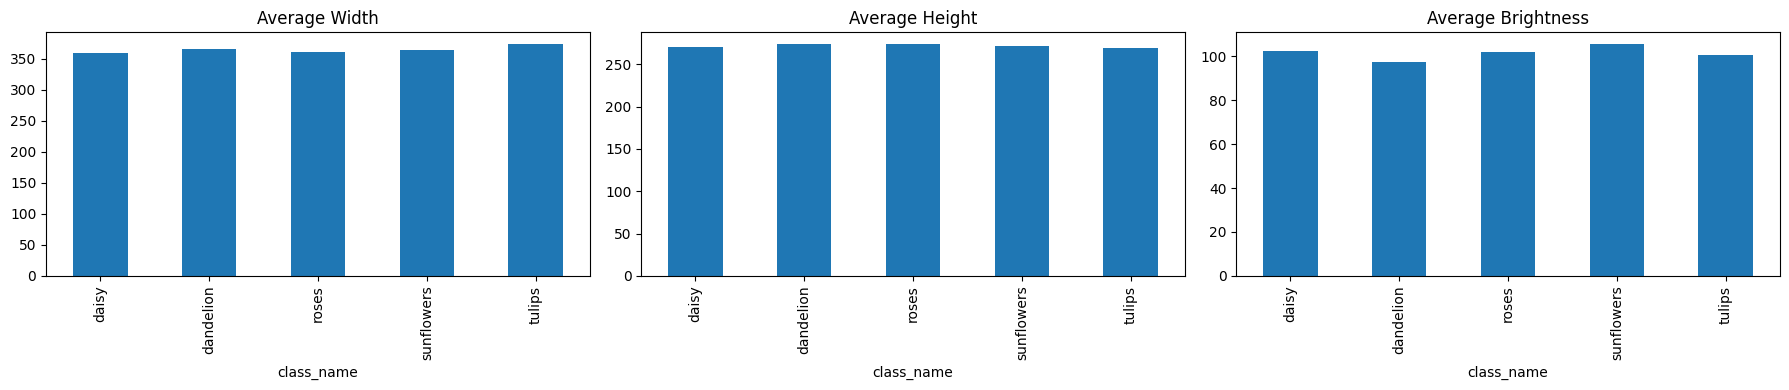

In [7]:
feature_df = pd.read_csv('models/feature_summary.csv')
display(feature_df)
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
feature_df.plot.bar(x='class_name', y='avg_width', ax=ax[0], legend=False, title='Average Width')
feature_df.plot.bar(x='class_name', y='avg_height', ax=ax[1], legend=False, title='Average Height')
feature_df.plot.bar(x='class_name', y='avg_brightness', ax=ax[2], legend=False, title='Average Brightness')
plt.tight_layout()

## 4. Prediction Correctness Demonstration\n
This cell chooses one test image, predicts, and compares predicted class to the ground-truth class from folder name.

In [ ]:
from pathlib import Path

# Safely find a test image with error handling
test_dir = Path('data/test')
if not test_dir.exists():
    print(f"Error: {test_dir} does not exist")
else:
    # Try to find jpg files
    jpg_files = list(test_dir.glob('*/*.jpg'))
    if not jpg_files:
        # Try jpeg files as fallback
        jpg_files = list(test_dir.glob('*/*.jpeg'))
    
    if not jpg_files:
        # List what's actually in the directory for debugging
        print("No jpg/jpeg files found. Directory structure:")
        for item in test_dir.rglob('*'):
            if item.is_file():
                print(f"  {item.relative_to(test_dir)}")
    else:
        sample_path = jpg_files[0]
        true_label = sample_path.parent.name
        pred = predict_image(str(sample_path))
        print('File:', sample_path)
        print('True Label:', true_label)
        print('Predicted Label:', pred['predicted_class'])
        print('Confidence:', pred['confidence'])
        print('Correct Prediction:', pred['predicted_class'] == true_label)


StopIteration: 

## 5. Artifact and Script Presence Check

In [ ]:
print('Model file (.keras) exists:', Path('models/flower_classifier.keras').exists())
print('Model file (.h5) exists:', Path('models/flower_classifier.h5').exists())
print('Retrain script exists:', Path('src/retrain.py').exists())
print('Prediction script exists:', Path('src/prediction.py').exists())
print('Metrics file exists:', Path('models/metrics.json').exists())
print('Confusion matrix exists:', Path('models/confusion_matrix.png').exists())